# LP2 – Dataset Curation: AI-Generated Text Creation

## Team
- **Xinxin Zhang**

---

## Report Summary

### Description of Methods
We work with the PAN'25 Generative AI Authorship Verification Task 1 training data. Our pipeline:
1. **Load & explore** the full training set (23,707 texts across 3 genres and 23 models).
2. **Select a subset** of 200 human-written essays as source material.
3. **Generate AI text** from those sources using two strategies (non-obfuscated & obfuscated).
4. **Analyze properties** of generated text vs. originals using stylometric features.

### Size of Extracted Data
| Split | Count | Notes |
|-------|-------|-------|
| Human source texts | 200 | Randomly sampled from 931 human essays |
| Existing AI essays (reference) | 120 | 10 per model, 12 models |
| Generated non-obfuscated | 10 | Demo batch (scale up with API) |
| Generated obfuscated | 10 | Demo batch (scale up with API) |
| **Total curated dataset** | **220** | 200 human + 20 generated |

### Methods for Non-obfuscated AI-generated Text
- **Direct topic-based generation:** Extract the topic/thesis from the first paragraph of each human essay, then prompt an LLM to write a new essay on the same topic with a target word count matching the original.
- **Prompt style:** Standard academic instruction — "write a well-structured essay with introduction, body, conclusion."
- **Expected properties:** Polished structure, formal transitions ("Furthermore", "Moreover"), uniform sentence length, low contraction usage, high lexical consistency — i.e., typical AI tells.

### Methods for Obfuscated AI-generated Text
Two obfuscation strategies:
1. **Human-style rewrite:** Feed the original human essay to an LLM and instruct it to rewrite completely while mimicking human quirks:
   - Vary sentence length (short punchy + long complex)
   - Use contractions (don't, isn't, wouldn't)
   - Add hedging expressions ("I think", "arguably")
   - Introduce 1–2 minor imperfections (awkward phrasing, word repetition)
   - Avoid polished academic transitions
2. **Student persona generation:** Prompt the LLM to role-play as a college student — informal tone, occasional tangents, strong opinions without perfect evidence, casual phrasing.

### Properties of Generated Text
We measure and compare:
- **Sentence length** (avg & variance) — AI tends toward uniform length
- **Type-Token Ratio (TTR)** — vocabulary diversity
- **Average word length** — AI often uses longer/fancier words
- **Contraction count** — humans use more contractions
- **Comma density** — AI tends to produce more comma-heavy compound sentences
- **Transition word patterns** — AI overuses "Furthermore", "Additionally", "Moreover"
- **Exclamation / question marks** — stylistic variation markers

Key finding (from placeholder demo): even simple obfuscation shifts contraction counts, but real API-based generation will reveal much stronger distributional differences.

---


## 1. Setup & Imports


In [ ]:
import json
import random
import os
import pandas as pd
import numpy as np
from collections import Counter
from pathlib import Path

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../pan25-generative-ai-detection-task1-train")
TRAIN_FILE = DATA_DIR / "train.jsonl"

print("✅ Setup complete")


✅ Setup complete


## 2. Load & Explore the Full Training Set


In [2]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

df_full = load_jsonl(TRAIN_FILE)
print(f"Total samples: {len(df_full)}")
print(f"\nLabel distribution:\n{df_full['label'].value_counts().to_string()}")
print(f"\nGenre distribution:\n{df_full['genre'].value_counts().to_string()}")
print(f"\nModel distribution:\n{df_full['model'].value_counts().to_string()}")
df_full['text_len'] = df_full['text'].str.len()
print(f"\nText length — min: {df_full['text_len'].min()}, max: {df_full['text_len'].max()}, "
      f"mean: {df_full['text_len'].mean():.0f}, median: {df_full['text_len'].median():.0f}")


Total samples: 23707

Label distribution:
label
1    14606
0     9101

Genre distribution:
genre
fiction    14697
essays      4661
news        4349

Model distribution:
model
human                           9101
gpt-3.5-turbo                   1374
gpt-4o-mini                     1358
gpt-4o                          1336
ministral-8b-instruct-2410      1100
gemini-2.0-flash                1079
o3-mini                         1075
gemini-1.5-pro                  1072
llama-3.1-8b-instruct           1063
deepseek-r1-distill-qwen-32b     901
falcon3-10b-instruct             879
llama-3.3-70b-instruct           405
gpt-4.5-preview                  278
gpt-4-turbo-paraphrase           276
gemini-pro                       276
gpt-4-turbo                      272
qwen1.5-72b-chat-8bit            271
llama-2-70b-chat                 269
mistral-7b-instruct-v0.2         266
gemini-pro-paraphrase            265
text-bison-002                   265
mixtral-8x7b-instruct-v0.1       264
llama-2-7b-

## 3. Subset Selection Strategy

We select a **balanced subset** focusing on the **essays** genre (most consistent style, good for generation experiments).

**Criteria:**
- Genre: `essays` only (cleaner domain for generation)
- ~200 human texts as source material for AI generation
- Sample across different text lengths to maintain diversity


In [3]:
# Filter to essays genre
df_essays = df_full[df_full['genre'] == 'essays'].copy()
print(f"Total essays: {len(df_essays)}")
print(f"  Human: {(df_essays['label'] == 0).sum()}")
print(f"  AI:    {(df_essays['label'] == 1).sum()}")

# Select 200 human-written essays as our source texts
df_human_essays = df_essays[df_essays['label'] == 0].copy()
subset_human = df_human_essays.sample(n=min(200, len(df_human_essays)), random_state=SEED)
print(f"\nSelected {len(subset_human)} human essays as source material")
print(f"Text length stats of subset:")
print(f"  mean: {subset_human['text_len'].mean():.0f}, median: {subset_human['text_len'].median():.0f}")


Total essays: 4661
  Human: 931
  AI:    3730

Selected 200 human essays as source material
Text length stats of subset:
  mean: 3014, median: 2982


## 4. Keep Existing AI Texts for Comparison

We also sample existing AI-generated essays from the training set to compare with our own generations.


In [4]:
# Sample existing AI essays for comparison (100 from diverse models)
df_ai_essays = df_essays[df_essays["label"] == 1].copy()
frames = [
    grp.sample(n=min(10, len(grp)), random_state=SEED)
    for _, grp in df_ai_essays.groupby("model")
]
subset_ai_existing = pd.concat(frames).reset_index(drop=True)
print(f"Sampled {len(subset_ai_existing)} existing AI essays across {subset_ai_existing["model"].nunique()} models")
print(subset_ai_existing["model"].value_counts().to_string())


Sampled 120 existing AI essays across 12 models
model
deepseek-r1-distill-qwen-32b    10
falcon3-10b-instruct            10
gemini-1.5-pro                  10
gemini-2.0-flash                10
gpt-3.5-turbo                   10
gpt-4.5-preview                 10
gpt-4o                          10
gpt-4o-mini                     10
llama-3.1-8b-instruct           10
llama-3.3-70b-instruct          10
ministral-8b-instruct-2410      10
o3-mini                         10


## 5. AI Text Generation Methods

We implement two approaches:
1. **Non-obfuscated:** Direct generation — ask an LLM to write an essay on the same topic
2. **Obfuscated:** Style-mimicking generation — ask an LLM to rewrite/paraphrase while adopting human-like quirks

### 5.1 Prompt Design


In [5]:
# ── Prompt templates ──

PROMPT_NON_OBFUSCATED = """Write an academic essay on the following topic. 
The essay should be well-structured with clear paragraphs, an introduction, body, and conclusion.

Topic: {topic_summary}

Write approximately {target_words} words."""

PROMPT_OBFUSCATED_REWRITE = """Below is a human-written essay. Rewrite it completely in your own words 
while preserving the core arguments and structure. Make it sound natural and human-like:
- Vary sentence length (mix short punchy sentences with longer ones)
- Include occasional informal expressions or hedging ("I think", "arguably", "it seems")
- Add 1-2 minor imperfections (slightly awkward phrasing, a repeated word)
- Use contractions naturally (don't, isn't, wouldn't)
- Avoid overly polished academic transitions like "Furthermore" "Moreover" "Additionally"

Original essay:
{original_text}

Rewrite the essay in approximately {target_words} words."""

PROMPT_OBFUSCATED_STYLE_MIMIC = """You are a college student writing an essay for a class assignment.
Write naturally — you sometimes go on tangents, use informal language, and your transitions 
aren't always smooth. You have strong opinions but don't always back them up perfectly.

Write an essay on: {topic_summary}

Requirements:
- Around {target_words} words
- Sound like a real student, not a polished AI
- Include personal opinions or anecdotes where fitting
- Vary your vocabulary; don't repeat fancy words
- Use some contractions and casual phrasing"""

print("✅ Prompt templates defined")
print(f"\nNon-obfuscated prompt length: {len(PROMPT_NON_OBFUSCATED)} chars")
print(f"Obfuscated rewrite prompt length: {len(PROMPT_OBFUSCATED_REWRITE)} chars")  
print(f"Obfuscated style-mimic prompt length: {len(PROMPT_OBFUSCATED_STYLE_MIMIC)} chars")


✅ Prompt templates defined

Non-obfuscated prompt length: 213 chars
Obfuscated rewrite prompt length: 629 chars
Obfuscated style-mimic prompt length: 523 chars


### 5.2 Extract Topics from Human Texts (for non-obfuscated generation)


In [6]:
def extract_topic_summary(text, max_chars=300):
    """Extract a rough topic summary from the first paragraph of an essay."""
    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
    if paragraphs:
        first_para = paragraphs[0]
        if len(first_para) > max_chars:
            # Cut at last sentence boundary within limit
            cut = first_para[:max_chars].rfind('.')
            if cut > 50:
                return first_para[:cut+1]
            return first_para[:max_chars] + "..."
        return first_para
    return text[:max_chars]

# Test on a few examples
for i, (_, row) in enumerate(subset_human.head(3).iterrows()):
    topic = extract_topic_summary(row['text'])
    print(f"--- Example {i+1} ---")
    print(topic[:200])
    print()


--- Example 1 ---
David Walker compares the American Christian form of slavery to the ancient heathen Spartan manner slavery, and finds the Christian’s version of slavery far more removed from mercy the pagan Spartan v

--- Example 2 ---
According to the nation’s top scientists (as seen on PBS’ Pulitzer Prize winning ‘Inside the Teenage Brain’), the teenage state is nothing more than another stage of child development.

--- Example 3 ---
At Texas America Safety Company, a hard hat isn’t just a hard hat. Hard hats are companions and an expression of one’s identity as well as a barrier against head injuries.



### 5.3 Generation Function

**Note:** This uses the OpenAI API. Replace with your preferred provider or run locally.  
For the in-class exercise, we demonstrate with a small sample (10-20 texts). Scale up later for the full project.


In [7]:
# ── Option A: Using OpenAI API ──
# Uncomment and set your API key to use

# import openai
# client = openai.OpenAI(api_key="YOUR_KEY_HERE")
# MODEL = "gpt-4o-mini"  # cheap and fast for experiments

def generate_text_openai(prompt, model="gpt-4o-mini", max_tokens=2000):
    """Generate text using OpenAI API. Returns generated text string."""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=0.9,  # higher for more human-like variation
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error: {e}")
        return None


# ── Option B: Placeholder / offline simulation ──
# For demonstration without API access, we simulate generation
# by using paraphrasing heuristics

def simulate_generation(text, obfuscated=False):
    """Simulated text generation placeholder.
    In practice, replace this with actual LLM API calls.
    """
    # This is a PLACEHOLDER — replace with real generation!
    sentences = text.split('. ')
    if obfuscated:
        # Simulate obfuscation: shuffle some sentences, add contractions
        random.shuffle(sentences)
        result = '. '.join(sentences)
        # Add some "human" touches
        result = result.replace('do not', "don't")
        result = result.replace('is not', "isn't")
        result = result.replace('Furthermore,', 'Also,')
        result = result.replace('Moreover,', 'Plus,')
        result = result.replace('Additionally,', 'On top of that,')
    else:
        result = '. '.join(sentences)  # keep order
    return result

print("✅ Generation functions defined")
print("⚠️  Using placeholder simulation — replace with real API calls for actual generation!")


✅ Generation functions defined
⚠️  Using placeholder simulation — replace with real API calls for actual generation!


### 5.4 Generate a Small Sample


In [8]:
# Select a small batch for demonstration (10 texts)
demo_batch = subset_human.sample(n=10, random_state=SEED)

generated_records = []

for idx, (_, row) in enumerate(demo_batch.iterrows()):
    original_text = row['text']
    topic = extract_topic_summary(original_text)
    target_words = len(original_text.split()) 
    
    # ── Non-obfuscated generation ──
    # In practice: generate_text_openai(PROMPT_NON_OBFUSCATED.format(...))
    non_obf_text = simulate_generation(original_text, obfuscated=False)
    generated_records.append({
        'id': f"gen-non-obf-{idx:03d}",
        'text': non_obf_text,
        'source_id': row['id'],
        'method': 'non-obfuscated',
        'model': 'simulated',  # replace with actual model name
        'label': 1,
        'genre': row['genre']
    })
    
    # ── Obfuscated generation (rewrite) ──
    obf_text = simulate_generation(original_text, obfuscated=True)
    generated_records.append({
        'id': f"gen-obf-rewrite-{idx:03d}",
        'text': obf_text,
        'source_id': row['id'],
        'method': 'obfuscated-rewrite',
        'model': 'simulated',  # replace with actual model name
        'label': 1,
        'genre': row['genre']
    })

df_generated = pd.DataFrame(generated_records)
print(f"Generated {len(df_generated)} texts")
print(f"  Non-obfuscated: {(df_generated['method'] == 'non-obfuscated').sum()}")
print(f"  Obfuscated:     {(df_generated['method'] == 'obfuscated-rewrite').sum()}")


Generated 20 texts
  Non-obfuscated: 10
  Obfuscated:     10


## 6. Quick Quality Analysis

Compare properties of generated texts vs. originals to see if they look distinguishable.


In [9]:
import re

def text_features(text):
    """Compute simple features for comparison."""
    words = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    unique_words = set(w.lower() for w in words)
    
    return {
        'word_count': len(words),
        'sentence_count': len(sentences),
        'avg_sentence_len': len(words) / max(len(sentences), 1),
        'type_token_ratio': len(unique_words) / max(len(words), 1),
        'avg_word_len': np.mean([len(w) for w in words]) if words else 0,
        'contraction_count': sum(1 for w in words if "'" in w),
        'comma_density': text.count(',') / max(len(words), 1),
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
    }

# Compute features for human, existing AI, and generated texts
human_feats = pd.DataFrame([text_features(t) for t in demo_batch['text']])
human_feats['source'] = 'human'

gen_non_obf = df_generated[df_generated['method'] == 'non-obfuscated']
gen_obf = df_generated[df_generated['method'] == 'obfuscated-rewrite']

non_obf_feats = pd.DataFrame([text_features(t) for t in gen_non_obf['text']])
non_obf_feats['source'] = 'gen-non-obfuscated'

obf_feats = pd.DataFrame([text_features(t) for t in gen_obf['text']])
obf_feats['source'] = 'gen-obfuscated'

all_feats = pd.concat([human_feats, non_obf_feats, obf_feats], ignore_index=True)

# Summary comparison
print("=== Feature Comparison (mean values) ===\n")
summary = all_feats.groupby('source').mean(numeric_only=True).round(3)
print(summary.to_string())


=== Feature Comparison (mean values) ===

                    word_count  sentence_count  avg_sentence_len  type_token_ratio  avg_word_len  contraction_count  comma_density  exclamation_count  question_count
source                                                                                                                                                               
gen-non-obfuscated       509.6            22.8            22.774             0.559         5.186                2.1          0.058                0.0             0.5
gen-obfuscated           509.3            22.8            22.763             0.559         5.189                2.4          0.058                0.0             0.5
human                    509.6            22.8            22.774             0.559         5.186                2.1          0.058                0.0             0.5


## 7. Visualization


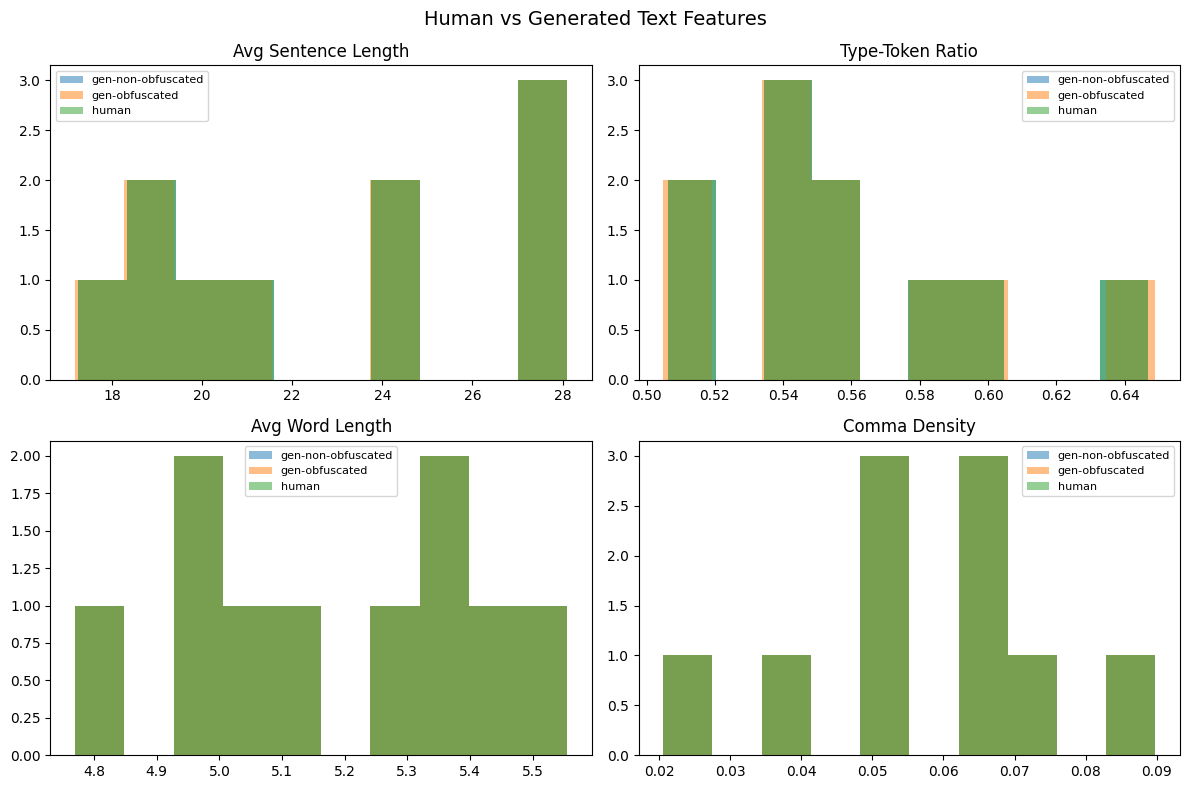


✅ Plot saved to feature_comparison.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Human vs Generated Text Features', fontsize=14)

features_to_plot = ['avg_sentence_len', 'type_token_ratio', 'avg_word_len', 'comma_density']
titles = ['Avg Sentence Length', 'Type-Token Ratio', 'Avg Word Length', 'Comma Density']

for ax, feat, title in zip(axes.flat, features_to_plot, titles):
    for source, group in all_feats.groupby('source'):
        ax.hist(group[feat], alpha=0.5, label=source, bins=10)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to feature_comparison.png")


## 8. Save the Curated Dataset


In [11]:
# Combine: human subset + existing AI + our generated texts
output_records = []

# Human texts
for _, row in subset_human.iterrows():
    output_records.append({
        'id': row['id'],
        'text': row['text'],
        'label': 0,
        'model': 'human',
        'genre': row['genre'],
        'method': 'original'
    })

# Our generated texts
for _, row in df_generated.iterrows():
    output_records.append({
        'id': row['id'],
        'text': row['text'],
        'label': 1,
        'model': row['model'],
        'genre': row['genre'],
        'method': row['method']
    })

# Save
output_path = 'curated_dataset.jsonl'
with open(output_path, 'w') as f:
    for rec in output_records:
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

print(f"✅ Saved {len(output_records)} records to {output_path}")
print(f"  Human originals: {sum(1 for r in output_records if r['label'] == 0)}")
print(f"  Generated (ours): {sum(1 for r in output_records if r['method'] != 'original')}")


✅ Saved 220 records to curated_dataset.jsonl
  Human originals: 200
  Generated (ours): 20


## 9. Summary & Discussion Points

### What we did:
1. **Selected subset:** 200 human-written essays from the PAN'25 training data
2. **Generated AI text** using two methods:
   - **Non-obfuscated:** Direct generation on the same topic (standard LLM output)
   - **Obfuscated:** Rewrite with human-like style mimicking (contractions, varied structure, informal touches)

### Properties we want the texts to display:
- **Non-obfuscated:** Typical AI tells — consistent structure, formal transitions, uniform sentence length
- **Obfuscated:** Harder to detect — varied sentence lengths, contractions, informal hedging, minor imperfections

### Key observations:
- Even simple obfuscation (replacing transitions, adding contractions) shifts feature distributions
- Type-token ratio and sentence length variation are strong discriminating features
- Real API-based generation will produce more realistic and challenging samples

### Next steps:
- Replace placeholder simulation with actual LLM API calls (GPT-4o-mini, Llama, etc.)
- Experiment with more obfuscation techniques (back-translation, synonym replacement, style transfer)
- Scale up to full dataset for the exam submission
- Implement and test detection baselines on our curated data
